# Text classification with Flair NLP

In this tutorial, we learn about basics of Flair NLP. We

- Take a glimpse at sequence tagging for named entity recognition (the initial use case for the Flair library)
-	Use public pretrained classifier for offensive language detection
-	Train and evaluate a classifier with the GermEval 2018 dataset
-	Predict labels from the CCS climate protest data set
-	Critically inspect results

First, we install the flair python package. With `!`, Colab allows the execution of programs on the command line. We can use `pip` to install any package needed in our runtime instance.

The package dependencies of flair also install all other necessary packages such as transformers.

This tutorial requires a GPU to be present. Otherwise execution of later steps will be painfully slow even for small data samples.

In Google COLAB: **Make sure to set the runtime instance type to "T4 GPU" instead of a basic CPU virtual machine** (in the Menu `Runtime` click `Change runtime type`). Only with a GPU we will have enough compute performance to train a transformer model!

In [1]:
%pip install flair

Note: you may need to restart the kernel to use updated packages.


Now we load necesary objects from flair.

Since flair is designed with short texts in mind, the `Sentence` is its primary data type. Although technically, a `Sentence` object can contain multiple sentences, thus, also be a short document.

Sentences can have labels, i.e. for classification. Sentences also contain `Token` objects. Token objects can have labels, too, e.g. for Sequence tagging.

As an example, we load a pretrained SequenceTagger to perform Named Entity Recognition (NER). This downloads a large model file that is loaded into the tagger object.

In [1]:
from flair.data import Sentence
from flair.models import SequenceTagger

# load the English NER tagger
tagger = SequenceTagger.load('ner')

pytorch_model.bin:   0%|          | 0.00/419M [00:00<?, ?B/s]

c:\Users\GregorWiedemann\miniconda3\envs\nlp\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\GregorWiedemann\.flair\models\ner-english\models--flair--ner-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


2026-07-07 23:18:32,455 SequenceTagger predicts: Dictionary with 20 tags: <unk>, O, S-ORG, S-MISC, B-PER, E-PER, S-LOC, B-ORG, E-ORG, I-PER, S-PER, B-MISC, I-MISC, E-MISC, I-ORG, B-LOC, E-LOC, I-LOC, <START>, <STOP>


We can now create Sentence objects from strings and use the predict method of the tagger to add labels to each token in a Sentence.

In [2]:
# make a sentence
sentence = Sentence('Her mother was Paris Hilton from Paris , Texas.')

# run NER over sentence
tagger.predict(sentence)

# print results
print(sentence)

# iterate over entities and print each
for entity in sentence.get_spans('ner'):
    print(entity)

Sentence[10]: "Her mother was Paris Hilton from Paris , Texas." → ["Paris Hilton"/PER, "Paris"/LOC, "Texas"/LOC]
Span[3:5]: "Paris Hilton" → PER (0.9177)
Span[6:7]: "Paris" → LOC (0.9991)
Span[8:9]: "Texas" → LOC (0.9999)


# Pretrained models

Flair can do also text classification, i.e. classification of entire sentences, short texts, or documents instead of single tokens spans. Let's try the pretrained model on German offensive language.

In [3]:
from flair.models import TextClassifier

# load classifier
flair_classifier = TextClassifier.load('de-offensive-language')

2026-07-07 23:20:31,193 https://nlp.informatik.hu-berlin.de/resources/models/de-offensive-language/germ-eval-2018-task-1-v0.8.pt not found in cache, downloading to C:\Users\GREGOR~1\AppData\Local\Temp\tmpkkjzar9q


100%|██████████| 419M/419M [00:37<00:00, 11.6MB/s] 

2026-07-07 23:21:09,382 copying C:\Users\GREGOR~1\AppData\Local\Temp\tmpkkjzar9q to cache at C:\Users\GregorWiedemann\.flair\models\germ-eval-2018-task-1-v0.8.pt


2026-07-07 23:21:09,615 removing temp file C:\Users\GREGOR~1\AppData\Local\Temp\tmpkkjzar9q


tokenizer_config.json:   0%|          | 0.00/83.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/362 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [4]:
# make example sentences
sentences = [
    Sentence("#Nuhr Der Typ ist ein schlechter Comedian, abgehalftert  und langsam altersstarsinnig."),
    Sentence("Ich bin einigermaßen entsetzt über die Wortwahl der #Ampel. Wir haben in der Debatte zum #Bürgergeld dieselben Zahlen verwendet wie der Bundesrechnungshof.")
]

# call predict on the classifier. It accepts single Sentence objects or lists of Sentence objects
flair_classifier.predict(sentences, label_name="offensive-lang")

# check predictions
for s in sentences:
  print(s)
  # with get_label, we can access the label info for each token
  print(s.get_label("offensive-lang").score, s.get_label("offensive-lang").value)

Sentence[14]: "#Nuhr Der Typ ist ein schlechter Comedian, abgehalftert  und langsam altersstarsinnig." → OFFENSE (1.0000)
1.0 OFFENSE
Sentence[26]: "Ich bin einigermaßen entsetzt über die Wortwahl der #Ampel. Wir haben in der Debatte zum #Bürgergeld dieselben Zahlen verwendet wie der Bundesrechnungshof." → OTHER (1.0000)
1.0 OTHER


The previous models did not rely on transformers, but on Flairs own embedding approach.

However, flair also wraps around transformer models such as BERT to perform embeddings or classification tasks.

We import the `TransformerWordEmbeddings` object to load the pretrained German language model `gbert-base` from [Chan et al. 2020](https://aclanthology.org/2020.coling-main.598/).

Here's the model card for it on huggingface: https://huggingface.co/deepset/gbert-base

In [5]:
from flair.embeddings import TransformerWordEmbeddings

# init german BERT model by deepset
bert_embedding = TransformerWordEmbeddings('deepset/gbert-large')

# embed each token in the sentence, i.e. compute the embedding according to the pretrained model
bert_embedding.embed(sentences)

# now check out the embedded first tokens.
for token in sentences[0][:2]:
    print(token)
    # each embedding is a vector of 768 float values
    print(token.embedding)

tokenizer_config.json:   0%|          | 0.00/83.0 [00:00<?, ?B/s]

c:\Users\GregorWiedemann\miniconda3\envs\nlp\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\GregorWiedemann\.cache\huggingface\hub\models--deepset--gbert-large. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.35G [00:00<?, ?B/s]

Token[0]: "#"
tensor([ 0.1965, -0.0859, -0.0368,  ...,  0.2668,  0.1960, -0.1573])
Token[1]: "Nuhr"
tensor([ 0.5772,  0.1617, -0.2286,  ..., -0.5320, -0.1489,  0.1020])


You could see that flair and the transformer model perform their own tokenizations. Let's look a bit deeper into the way how transformers split strings into tokens.

The tokenizer is bundled with the model to ensure exact reproduction of tokens for the neural network input. It uses so called [SentencePiece tokenization](https://arxiv.org/abs/1808.06226) which splits a sentence into precomputed sub words.

In [6]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("deepset/gbert-large")
encoded_input = tokenizer("#Nuhr Der Typ ist ein schlechter Comedian, abgehalftert  und langsam altersstarsinnig.")

In [7]:
encoded_input.tokens()

['[CLS]',
 '#',
 'Nu',
 '##hr',
 'Der',
 'Typ',
 'ist',
 'ein',
 'schlechter',
 'Come',
 '##dia',
 '##n',
 ',',
 'abge',
 '##hal',
 '##fter',
 '##t',
 'und',
 'langsam',
 'alter',
 '##sst',
 '##ars',
 '##inn',
 '##ig',
 '.',
 '[SEP]']

The Flair library utilizes a more human friendly tokenization into complete words and maps words to word pieces internally.

# Train a transformer text classifier

Now let's train a text classifier for offensive language detection.

First, we mount the training data from GDrive

In [8]:
use_google_drive = False
if use_google_drive:
    from google.colab import drive
    drive.mount('/content/gdrive')
    %cd /content/gdrive/MyDrive/FLACA-Workshop

And load a dataset (the test data set only, since it is smaller)

In [9]:
import pandas as pd
import numpy as np
import os
# load the csv with pandas
df_train = pd.read_csv("data/germeval2018.training.tsv", delimiter="\t", header=None)
# name the columns
df_train.columns = ["text", "coarse", "fine"]
# inspect the df
df_train

,text,coarse,fine
0,"@corinnamilborn Liebe Corinna, wir würden dich...",OTHER,OTHER
1,@Martin28a Sie haben ja auch Recht. Unser Twee...,OTHER,OTHER
2,@ahrens_theo fröhlicher gruß aus der schönsten...,OTHER,OTHER
3,@dushanwegner Amis hätten alles und jeden gewä...,OTHER,OTHER
4,@spdde kein verläßlicher Verhandlungspartner. ...,OFFENSE,INSULT
...,...,...,...
5004,Gegens. Zul. zu Patenamt &amp; gegenseitige An...,OTHER,OTHER
5005,"@GlasenappHenrik Zu Merkel fällt mir nur ein, ...",OFFENSE,INSULT
5006,@KokoLores20 @krippmarie Ein richtiges Zeichen...,OFFENSE,ABUSE
5007,"@Hartes_Geld ,Honecker‘Merkel macht uns zur ,D...",OFFENSE,ABUSE


In [10]:
# now the test data
df_test = pd.read_csv("data/germeval2018.test.tsv", delimiter="\t", header=None)
df_test.columns = ["text", "coarse", "fine"]
df_test

,text,coarse,fine
0,"Meine Mutter hat mir erzählt, dass mein Vater ...",OTHER,OTHER
1,@Tom174_ @davidbest95 Meine Reaktion; |LBR| Ni...,OTHER,OTHER
2,"#Merkel rollt dem Emir von #Katar, der islamis...",OTHER,OTHER
3,„Merle ist kein junges unschuldiges Mädchen“ K...,OTHER,OTHER
4,@umweltundaktiv Asylantenflut bringt eben nur ...,OFFENSE,ABUSE
...,...,...,...
3393,"@schlabonski tja, es können einen nicht alle L...",OTHER,OTHER
3394,"@RKnillmann @lawyerberlin @AfD Aha, der Islam ...",OFFENSE,ABUSE
3395,"@podilein Mannheim, weltoffen und kunterbunt. ...",OFFENSE,ABUSE
3396,@stephanweil was ist nun mit kostenlosen Kitas...,OTHER,OTHER


Since the dataset comprises only of training and test splits, we create another dev split from the training data. Then, we write it as three CSV files into a separate folder to disk, since this is the format flair NLP prefers for handling corpus data.

In [11]:
from sklearn.model_selection import train_test_split
from pathlib import Path

# train_test_split works also with pandas dataframes
df_train, df_dev = train_test_split(df_train, test_size=0.1, random_state=1)

# export as
path = "flair_germeval2018_corpus"
Path(path).mkdir(exist_ok = True)
df_train.to_csv(path + "/train.csv", sep="\t")
df_dev.to_csv(path + "/dev.csv", sep="\t")
df_test.to_csv(path + "/test.csv", sep="\t")

This folder can be imported as a `CSVClassificationCorpus` object defining the column numbers for text and label and giving a name for the label_type.

In [12]:
from flair.datasets import CSVClassificationCorpus
corpus = CSVClassificationCorpus("flair_germeval2018_corpus/",
  {1: "text", 2: "label"},
  skip_header=True,
  label_type="OLD",
  delimiter='\t'
)

2026-07-07 23:28:01,630 Reading data from flair_germeval2018_corpus
2026-07-07 23:28:01,632 Train: flair_germeval2018_corpus\train.csv
2026-07-07 23:28:01,633 Dev: flair_germeval2018_corpus\dev.csv
2026-07-07 23:28:01,634 Test: flair_germeval2018_corpus\test.csv


Look into a sample sentence

In [13]:
corpus.train[4]

Sentence[9]: "@Rumsucher Sachsens Frauen für die Freiheit!!!" → OTHER (1.0000)

Get some corpus statistics from Flair

In [14]:
print(corpus.obtain_statistics())

{
    "TRAIN": {
        "dataset": "TRAIN",
        "total_number_of_documents": 4508,
        "number_of_documents_per_class": {
            "OTHER": 2975,
            "OFFENSE": 1533
        },
        "number_of_tokens_per_tag": {},
        "number_of_tokens": {
            "total": 118772,
            "min": 5,
            "max": 117,
            "avg": 26.346938775510203
        }
    },
    "TEST": {
        "dataset": "TEST",
        "total_number_of_documents": 3398,
        "number_of_documents_per_class": {
            "OTHER": 2248,
            "OFFENSE": 1150
        },
        "number_of_tokens_per_tag": {},
        "number_of_tokens": {
            "total": 80500,
            "min": 5,
            "max": 850,
            "avg": 23.690406121247793
        }
    },
    "DEV": {
        "dataset": "DEV",
        "total_number_of_documents": 501,
        "number_of_documents_per_class": {
            "OFFENSE": 155,
            "OTHER": 346
        },
        "number_of_toke

We need a transformer embedding object and a model trainer object to perform fine-tuning of a transformer model.

In [15]:
from flair.trainers import ModelTrainer
from flair.embeddings import TransformerDocumentEmbeddings

Also flair uses label dictionaries to identify different labels for different classification tasks on a sentence/token object. We can create a label dictionary from the loaded corpus.

In [16]:
label_dictionary = corpus.make_label_dictionary(label_type="OLD")

2026-07-07 23:28:23,814 Computing label dictionary. Progress:


0it [00:00, ?it/s]
4508it [00:01, 2487.83it/s]

2026-07-07 23:28:25,641 Dictionary created for label 'OLD' with 2 values: OTHER (seen 2975 times), OFFENSE (seen 1533 times)


Now, we define the actual classifier with the target label dictionary and some other parameters (read the documentation) and run the fine tuning.

Flair automatically trains the network for max_epochs numbers of epochs (runs over the training data). After each epoch the dev set performance is evaluated. Only, if the model improved it is saved as new best model. This approach is supposed to prevent overfitting.

Here is a documentation of the possible parameters: https://huggingface.co/docs/transformers/main_classes/trainer#transformers.TrainingArguments ... only a small fraction of them is usually consideref for optimization (learning rate, learning rate scheduler, batch size, ...)

In [ ]:
# define the classifer
classifier = TextClassifier(
    embeddings=TransformerDocumentEmbeddings(
        'deepset/gbert-large',
        fine_tune=True,
        layers='-1'
    ),
    label_dictionary=label_dictionary,
    label_type="OLD",
    multi_label=False
)

# create a trainer object
trainer = ModelTrainer(classifier, corpus) # .downsample(0.2)

# run fine tuning (on the GPU!)
res = trainer.fine_tune(
    'flair_models/old-large',
    learning_rate=5e-6,
    mini_batch_size=8,
    warmup_fraction=0.1,
    train_with_dev=False,
    max_epochs=30, # HINT: 10 is a preferred default value when training with a linear scheduler with warmup; we just use 4 here to not waste too much time during the workshop
    main_evaluation_metric = ("macro avg", 'f1-score'),
    use_final_model_for_eval = False,
    save_final_model = False,
    #write_weights = False,
    #epoch = self.epochs_trained
)
print(res)

2026-07-07 23:28:29,794 ----------------------------------------------------------------------------------------------------
2026-07-07 23:28:29,798 Model: "TextClassifier(
  (embeddings): TransformerDocumentEmbeddings(
    (model): BertModel(
      (embeddings): BertEmbeddings(
        (word_embeddings): Embedding(31103, 1024, padding_idx=0)
        (position_embeddings): Embedding(512, 1024)
        (token_type_embeddings): Embedding(2, 1024)
        (LayerNorm): LayerNorm((1024,), eps=1e-12, elementwise_affine=True, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (encoder): BertEncoder(
        (layer): ModuleList(
          (0-23): 24 x BertLayer(
            (attention): BertAttention(
              (self): BertSdpaSelfAttention(
                (query): Linear(in_features=1024, out_features=1024, bias=True)
                (key): Linear(in_features=1024, out_features=1024, bias=True)
                (value): Linear(in_features=1024, out_features=1024, bi

c:\Users\GregorWiedemann\miniconda3\envs\nlp\Lib\site-packages\flair\trainers\trainer.py:545: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp and flair.device.type != "cpu")


The final model is not necessarily the best model. During training, Flair evaluates the performance after each epoch (one complete iteration over the training set) w.r.t. the dev set performance. If the current model state exceeds the best previous performance, it is saved to disk.

In the end, we load the best model and evaluate it on the hold-out test set.

In [ ]:
# Hint: look into flair_models/old/ to find some useful outputs from the Flair training process
model = TextClassifier.load('flair_models/old/best-model.pt')
res = model.evaluate(corpus.test, gold_label_type="OLD")
print(res)

## gbert-base 4 epochs
```
Results:
- F-score (micro) 0.8034
- F-score (macro) 0.7625
- Accuracy 0.8034

By class:
              precision    recall  f1-score   support

       OTHER     0.8086    0.9208    0.8611      2248
     OFFENSE     0.7876    0.5739    0.6640      1150

    accuracy                         0.8034      3398
   macro avg     0.7981    0.7474    0.7625      3398
weighted avg     0.8015    0.8034    0.7944      3398

Loss: 0.591874897480011'
```



Let's validate the trained model. We predict labels for two samples.

In [ ]:
examples = [
    Sentence("#ardextra #GEZ Wer schaut sich noch dieses Propagandamüll im zwangsfinanzierten Staatsfunk noch an?"),
    Sentence("Kritik unerwünscht\n Der Trainer von Bayern München demonstrierte eindrucksvoll, weshalb er als gefährlicher Angreifer gilt.")
]
model.predict(examples)
print(examples)

Additional things to deal with:
* **Stability of results:** Repeated runs of model training result in different performances. To determine a realistic performance measure, one typically repeats model training and evaluation n times (e.g. 5) and reports average performance measures together with their standard deviation.
* **Model selection / hyperparameter optimization:** Different pretrained models and different hyperparameters for model fine tuning affect their final performance. To identify best parameter settings, one can employ a grid search (or most elaborate tuning measures) over a range of parameters. Again, instability of results over repeated runs requires a repetition of training for one parameter setup to make sure that better performance is not an effect of randomness.
  * Model size: you can try to use another pretrained language model, e.g. 'deepset/gbert-large'
  * Epochs: let the training run for 10, 20, 30, ... epochs and compare the results. When does further training not improve the result?
  * Batch size and learning rate: changing these parameters may have smaller effects on the performance, too. Best way to find out is to test different values in a certain range. But, this can become quite time-consuming fast ...

# Does our classifier beat the publicly available Flair model?

Let's compare the performance of the flair model to ours.

In [ ]:
res = flair_classifier.evaluate(corpus.test, gold_label_type="OLD")
print(res)

Looks like we could make some effort to improve our model :)

* train for 10+ epochs
* use the `deepset/gbert-large` model that has more parameters
* optimize batch size and learning rate

# Predict unseen data

Let's use our model to predict offensive tweets from another context.

## Twitter climate protest dataset

We classify tweets from a climate debate context from the year 2022 that were either mentioning Fridays for Furture or The Last Generation.

> twarc2 search –archive –start-time “2022-01-01” –end-time “2022-12-31” “letztegeneration OR (letzte generation) OR aufstandlastgen lang:de” letztegeneration-2022.jsonl

1468398 tweets total

> twarc2 search –archive –start-time “2022-01-01” –end-time “2022-12-31” “fridaysforfuture OR (fridays for future) OR FFF lang:de” fridaysforfuture-2022.jsonl

913750 tweets total

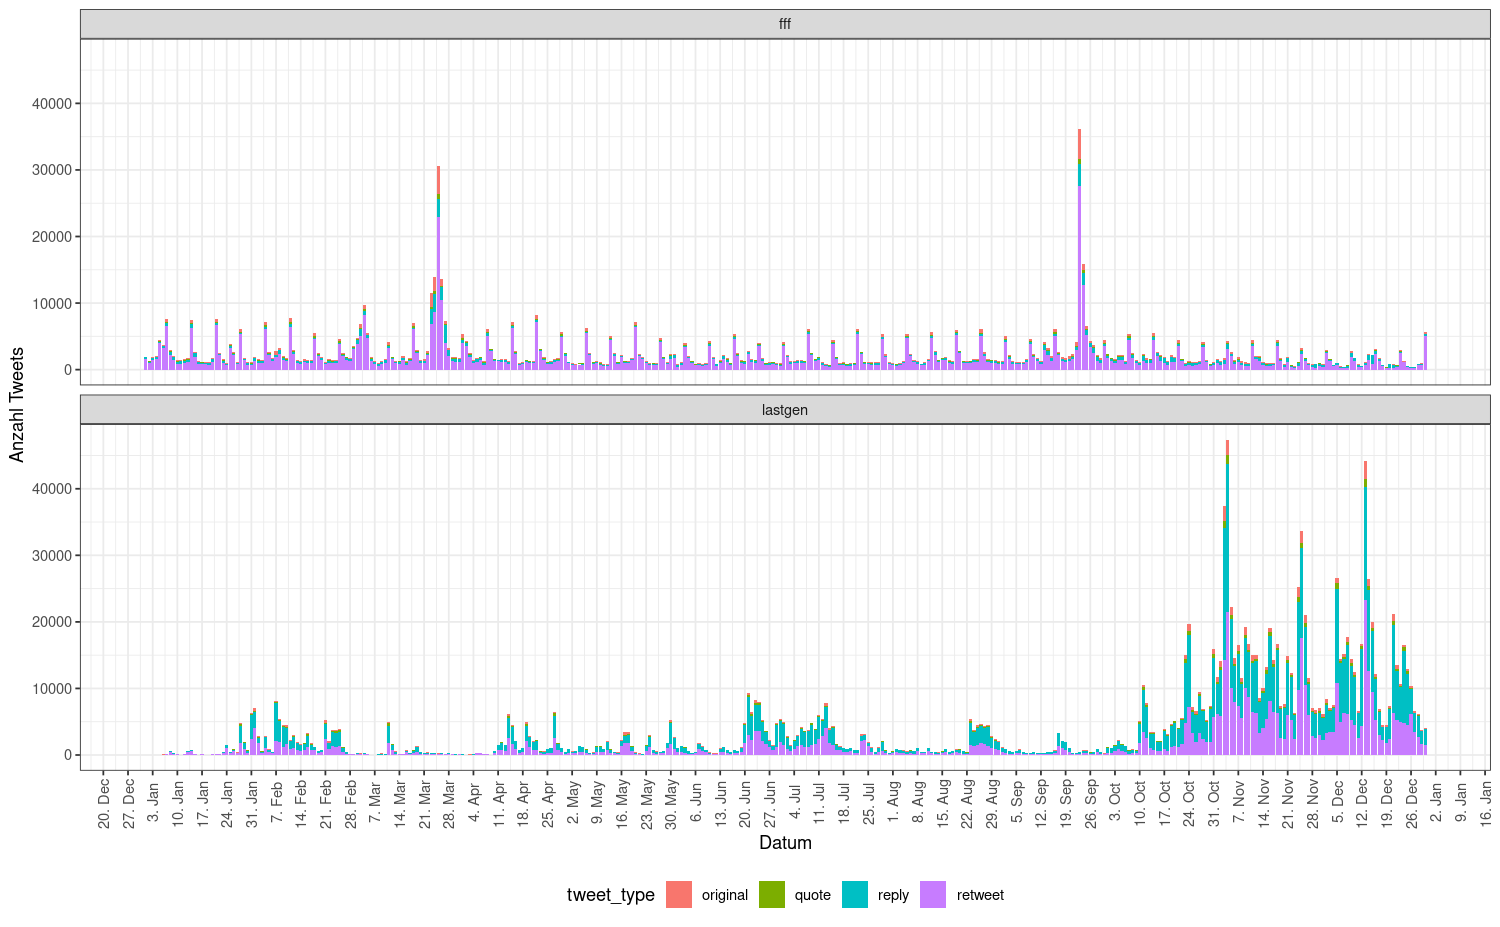

We use a version of the dataset that contains a 5 % sample of all German language tweets fro that year matching the keyword filter criterion for one of the two groups.

In [ ]:
# load prediction sample
ccs_df = pd.read_csv("data/ccs-tweets_5-percent-sample.csv.gz")
ccs_df

To save some time, let's predict labels only for a smaller sample of the dataset.

In [ ]:
ccs_sample = ccs_df.sample(n=10000) # Sample 100 random rows

Now, let's predict some labels and collect the corresponding scores!

In [ ]:
from tqdm.notebook import tqdm

def chunker(seq, size):
    return (seq[pos:pos + size] for pos in range(0, len(seq), size))

tweet_texts = ccs_sample['text']
predicted_labels = []
predicted_scores = []

# Predict labels for each tweet
batch_size = 1000
for chunk in tqdm(chunker(tweet_texts, batch_size), total=int(len(tweet_texts) / batch_size)):

    # Create a list of Flair sentence objects from the 'text' column of the DataFrame
    sentences = [Sentence(text) for text in chunk]
    model.predict(sentences, label_name="OLD")

    # Extract the predicted labels and scores
    for sentence in sentences:
        label = sentence.get_label("OLD")
        predicted_labels.append(label.value)
        predicted_scores.append(label.score)

# Add the predictions as new columns to the DataFrame
ccs_sample['predicted_label'] = predicted_labels
ccs_sample['predicted_score'] = predicted_scores

# Display or further process the DataFrame with the predictions
ccs_sample

Which group get's more offensive mentions on Twitter?

In [ ]:
# Group by 'protest' and count different values of 'predicted_label'
label_counts = ccs_sample.groupby('protest')['predicted_label'].value_counts()

label_counts

Let us visualize this as a bar plot

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'label_counts' is the Series from the previous cell
label_counts.unstack().plot(kind='bar', stacked=True)
plt.xlabel("Protest")
plt.ylabel("Count")
plt.title("Predicted Labels by Protest")
plt.show()

In [ ]:
# Filter for rows where predicted_label is "OFFENSE"
offense_rows = ccs_sample[ccs_sample['predicted_label'] == "OFFENSE"]

# Sort by predicted_score in descending order and take the top 10
top_10_offenses = offense_rows.sort_values(by='predicted_score', ascending=False).head(10)

# Print the top 10 rows
top_10_offenses

In [ ]:
# Sort by predicted_score in ascending order and take the top 10
top_10_uncertain_offenses = offense_rows.sort_values(by='predicted_score', ascending=True).head(10)

# Print the top 10 rows: How convincing is thw classification?
top_10_uncertain_offenses

# Optional exercises

How are the scores distributed? Are there many uncertain examples or the the classifier basically certain for most cases? A histogram plot might give us a good impression.

In [ ]:
# Your code here ... don't be shy of asking Gemini AI!

In [ ]:
# prompt: Create a  histogram plot for the column predicted_score in the data frame ccs_sample

plt.hist(ccs_sample['predicted_score'], bins=20)
plt.xlabel('Predicted Score')
plt.ylabel('Frequency')
plt.title('Histogram of Predicted Scores')
plt.show()

What are the most used words (excluding stop words) from all offensive posts related to
* FFF, compared to
* LastGen?

You can use the CountVectorizer object from sklearn.